
Performance report saved successfully.


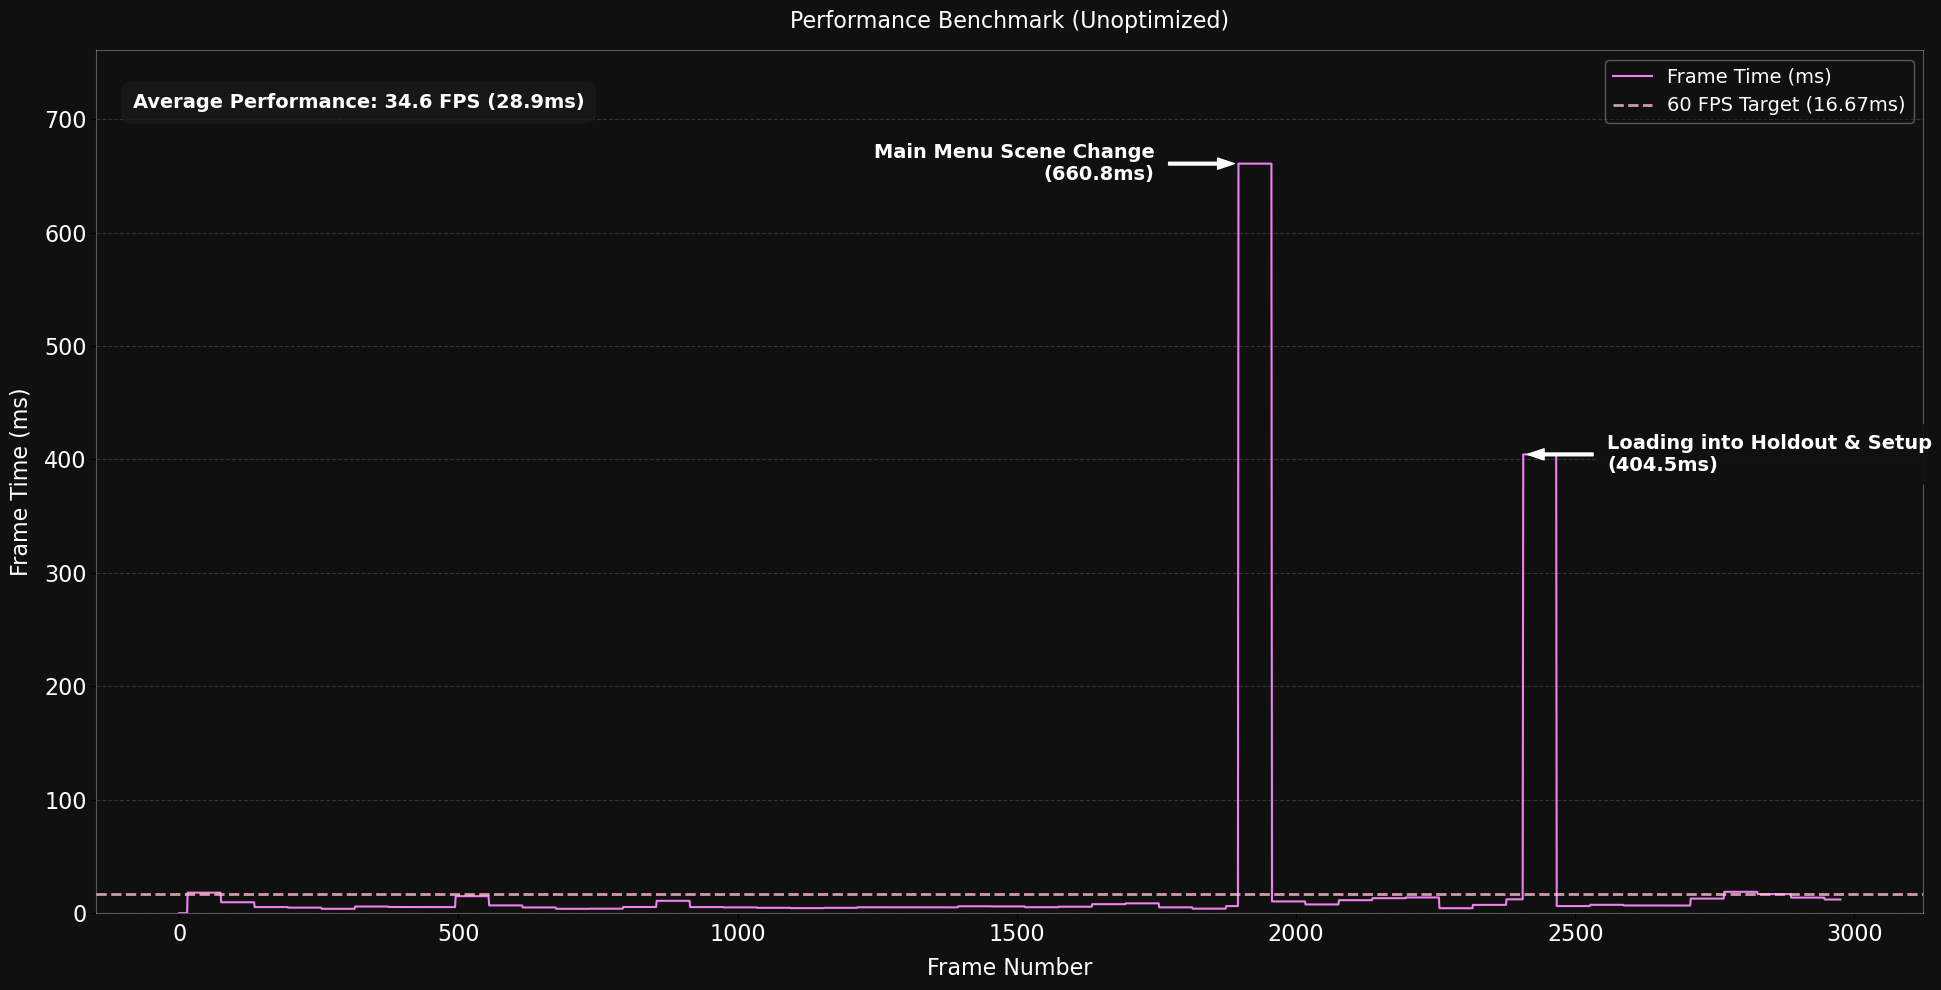

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plotPerformanceVisualizationFinal(csv_file):
    df = pd.read_csv(csv_file)

    plt.figure(figsize=(20, 10), facecolor='#101010')
    currentAxes = plt.gca()
    currentAxes.set_facecolor('#101010')

    plt.plot(df.index, df['FrameTime_ms'], color='#ee82ee', linewidth=1.5, label='Frame Time (ms)')

    plt.axhline(y=16.67, color='#ffc0cb', linestyle='--', linewidth=2, alpha=0.8, label='60 FPS Target (16.67ms)')

    # Find the two largest spikes
    max_idx = df['FrameTime_ms'].idxmax()
    max_val = df['FrameTime_ms'].max()
    
    masked_df = df.copy()
    masked_df.loc[max(0, max_idx-200):min(len(masked_df), max_idx+200), 'FrameTime_ms'] = 0
    second_max_idx = masked_df['FrameTime_ms'].idxmax()
    second_max_val = masked_df['FrameTime_ms'].max()
    
    if max_idx > second_max_idx:
        max_idx, second_max_idx = second_max_idx, max_idx
        max_val, second_max_val = second_max_val, max_val

    plt.annotate(
        f'Main Menu Scene Change\n({max_val:.1f}ms)', 
        xy=(max_idx, max_val), 
        xytext=(max_idx - 150, max_val),
        color='white',
        fontsize=14,
        fontweight='bold',
        arrowprops=dict(facecolor='white', edgecolor='white', shrink=0.05, width=2, headwidth=8),
        ha='right',
        va='center',
        bbox=dict(boxstyle="round,pad=0.5", fc="#101010", ec="none", alpha=0.9)
    )

    plt.annotate(
        f'Loading into Holdout & Setup\n({second_max_val:.1f}ms)', 
        xy=(second_max_idx, second_max_val), 
        xytext=(second_max_idx + 150, second_max_val),
        color='white',
        fontsize=14,
        fontweight='bold',
        arrowprops=dict(facecolor='white', edgecolor='white', shrink=0.05, width=2, headwidth=8),
        ha='left',
        va='center',
        bbox=dict(boxstyle="round,pad=0.5", fc="#101010", ec="none", alpha=0.9)
    )

    avg_frame_time = df['FrameTime_ms'].mean()
    avg_fps = 1000.0 / avg_frame_time if avg_frame_time > 0 else 0
    
    plt.text(
        0.02, 0.95,
        f'Average Performance: {avg_fps:.1f} FPS ({avg_frame_time:.1f}ms)',
        transform=currentAxes.transAxes,
        color='white',
        fontsize=14,
        fontweight='bold',
        va='top',
        bbox=dict(boxstyle="round,pad=0.6", fc="#1a1a1a", ec="none", alpha=0.8)
    )

    plt.yticks(fontsize=16, color='white')
    plt.xticks(fontsize=16, color='white') 
    plt.xlabel('Frame Number', fontsize=16, labelpad=8, color='white')
    plt.ylabel('Frame Time (ms)', fontsize=16, labelpad=8, color='white')
    plt.title('Performance Benchmark (Unoptimized)', fontsize=16, pad=16, color='white')

    plt.grid(axis='y', linestyle='--', alpha=0.15, color='white')
    legend = plt.legend(loc='upper right', frameon=True, facecolor="#101010", fontsize=14, labelcolor='white')

    legend.get_frame().set_edgecolor('white')
    legend.get_frame().set_alpha(0.3)

    for spine in currentAxes.spines.values():
        spine.set_color('white')
        spine.set_alpha(0.3)
        
    plt.ylim(0, df['FrameTime_ms'].max() + 100)

    plt.tight_layout()
    plt.savefig('finalGraphs/unoptimized_benchmark.png', dpi=300)
    print("\nPerformance report saved successfully.")

plotPerformanceVisualizationFinal('unoptimizedBenchmark.csv')

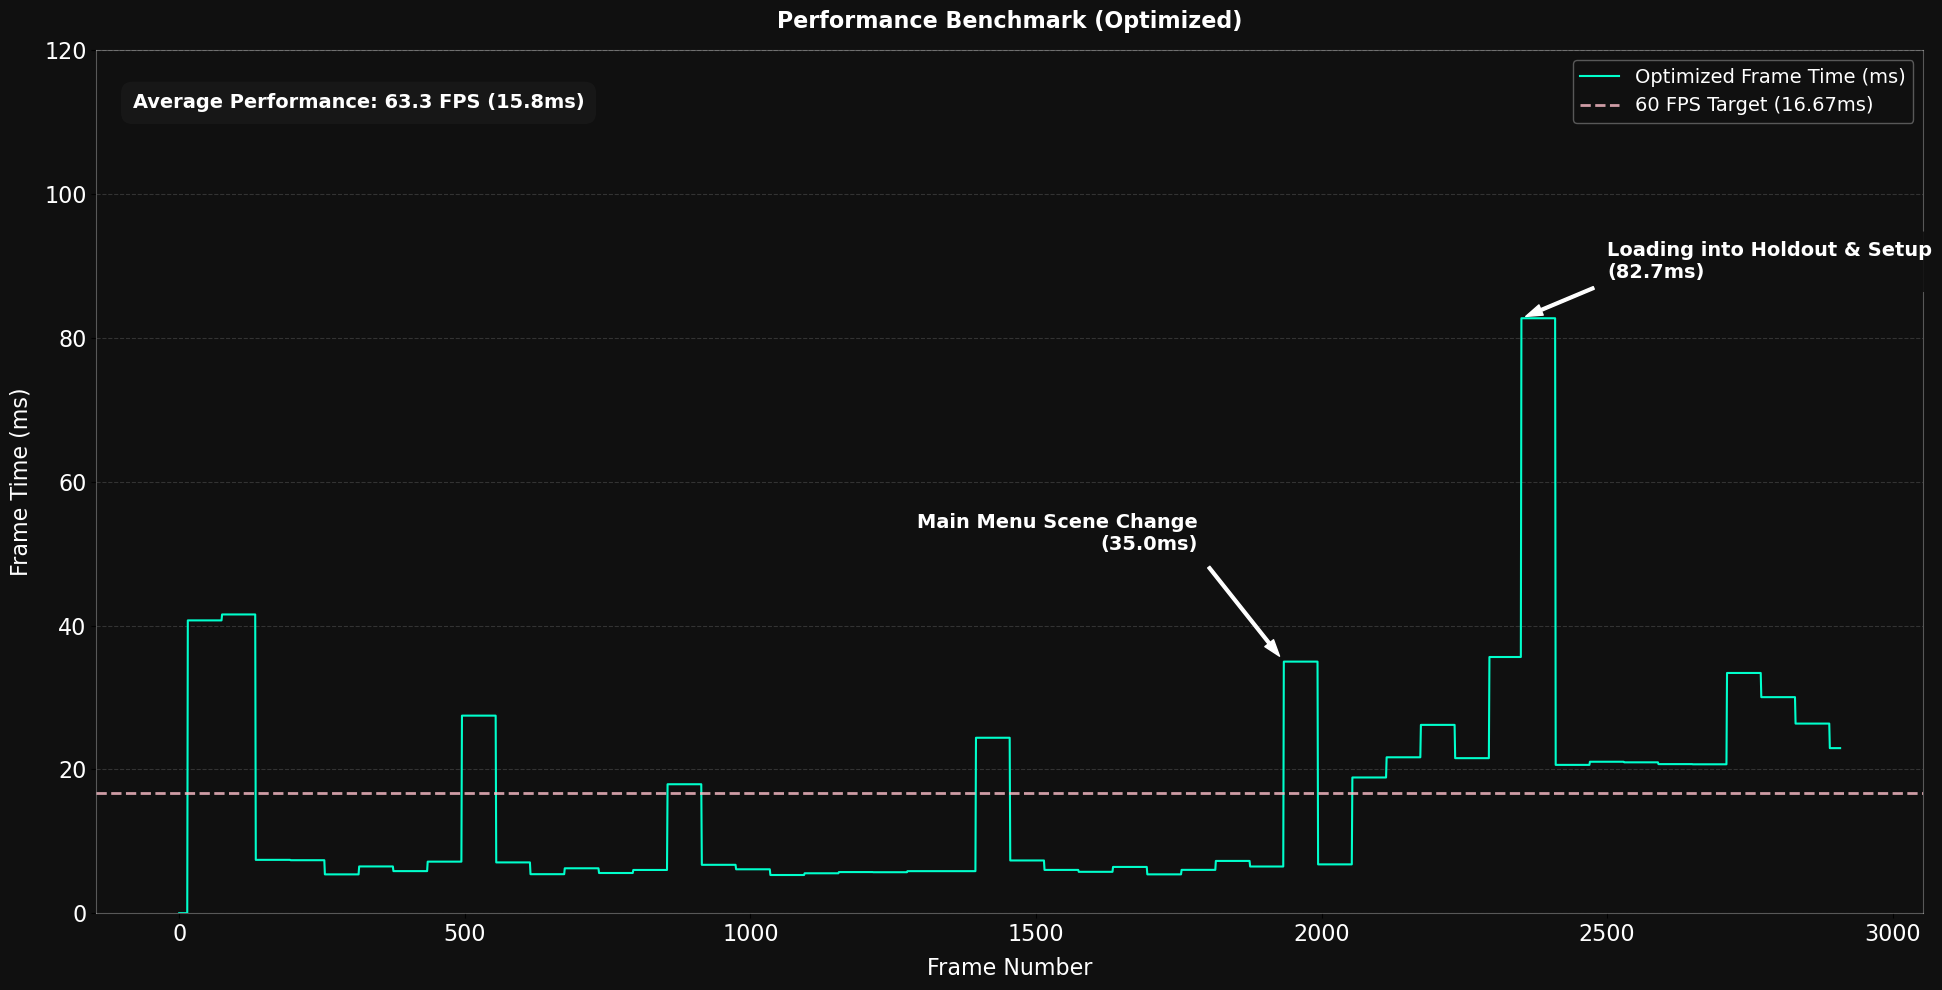

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plotOptimizedPerformanceVisualizationCorrected(csv_file):
    df = pd.read_csv(csv_file)

    plt.figure(figsize=(20, 10), facecolor='#101010')
    currentAxes = plt.gca()
    currentAxes.set_facecolor('#101010')

    plt.plot(df.index, df['FrameTime_ms'], color='#00FFCC', linewidth=1.5, label='Optimized Frame Time (ms)')

    plt.axhline(y=16.67, color='#ffc0cb', linestyle='--', linewidth=2, alpha=0.8, label='60 FPS Target (16.67ms)')

    main_menu_window = df.loc[1800:2100]
    max_idx = main_menu_window['FrameTime_ms'].idxmax()
    max_val = main_menu_window['FrameTime_ms'].max()
    
    holdout_window = df.loc[2200:2800]
    second_max_idx = holdout_window['FrameTime_ms'].idxmax()
    second_max_val = holdout_window['FrameTime_ms'].max()

    plt.annotate(
        f'Main Menu Scene Change\n({max_val:.1f}ms)', 
        xy=(max_idx, max_val), 
        xytext=(max_idx - 150, max_val + 15),
        color='white',
        fontsize=14,
        fontweight='bold',
        arrowprops=dict(facecolor='white', edgecolor='white', shrink=0.05, width=2, headwidth=8),
        ha='right',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.5", fc="#101010", ec="none", alpha=0.9)
    )

    plt.annotate(
        f'Loading into Holdout & Setup\n({second_max_val:.1f}ms)', 
        xy=(second_max_idx, second_max_val), 
        xytext=(second_max_idx + 150, second_max_val + 5),
        color='white',
        fontsize=14,
        fontweight='bold',
        arrowprops=dict(facecolor='white', edgecolor='white', shrink=0.05, width=2, headwidth=8),
        ha='left',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.5", fc="#101010", ec="none", alpha=0.9)
    )

    avg_frame_time = df['FrameTime_ms'].mean()
    avg_fps = 1000.0 / avg_frame_time if avg_frame_time > 0 else 0
    
    plt.text(
        0.02, 0.95,
        f'Average Performance: {avg_fps:.1f} FPS ({avg_frame_time:.1f}ms)',
        transform=currentAxes.transAxes,
        color='white',
        fontsize=14,
        fontweight='bold',
        va='top',
        bbox=dict(boxstyle="round,pad=0.6", fc="#1a1a1a", ec="none", alpha=0.8)
    )

    plt.yticks(fontsize=16, color='white')
    plt.xticks(fontsize=16, color='white') 
    plt.xlabel('Frame Number', fontsize=16, labelpad=8, color='white')
    plt.ylabel('Frame Time (ms)', fontsize=16, labelpad=8, color='white')
    plt.title('Performance Benchmark (Optimized)', fontsize=16, pad=16, color='white', fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.15, color='white')
    legend = plt.legend(loc='upper right', frameon=True, facecolor="#101010", fontsize=14, labelcolor='white')

    legend.get_frame().set_edgecolor('white')
    legend.get_frame().set_alpha(0.3)

    for spine in currentAxes.spines.values():
        spine.set_color('white')
        spine.set_alpha(0.3)
        
    plt.ylim(0, max(120, second_max_val + 25))

    plt.tight_layout()
    plt.savefig('finalGraphs/optimized_benchmark.png', dpi=300)

plotOptimizedPerformanceVisualizationCorrected('optimizedBenchmark.csv')